# 02 – Bull & Bear Labeling

---

### Vad gör vi i den här notebooken?

Innan vi kan träna några modeller behöver vi definiera vad som räknas som en **bull-** respektive **bear-marknad**. Vi använder en långsiktig regelbaserad definition med tillgångsspecifika trösklar:

- 🔴 **Bear market** – priset faller under tröskeln från senaste topp **och håller sig där i minst 60–90 dagar**
- 🟢 **Bull market** – priset stiger över tröskeln från senaste botten **och håller sig där i minst 60–90 dagar**

| Tillgång | Bear-tröskel | Bull-tröskel | Min. varaktighet |
|----------|-------------|-------------|------------------|
| S&P 500  | -20%        | +20%        | 60 dagar         |
| Bitcoin  | -60%        | +60%        | 90 dagar         |
| Guld     | -20%        | +20%        | 60 dagar         |

Bitcoin använder en högre tröskel eftersom 20%-rörelser är normalt brus för kryptovalutor. De historiska bear markets har sett nedgångar på 70–86%.

Dessa etiketter fungerar som vår **ground truth** – det vill säga det "rätta svaret" som alla modeller sedan tränas och utvärderas mot.

**Input:**  `data/sp500.csv`, `data/bitcoin.csv`, `data/gold.csv`  
**Output:** `data/sp500_labeled.csv`, `data/bitcoin_labeled.csv`, `data/gold_labeled.csv`

## 1. Importera bibliotek

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR    = '../data'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('✓ Bibliotek importerade')

✓ Bibliotek importerade


## 2. Läs in data

Vi läser in de separata CSV-filerna som skapades i `01_data_collection.ipynb`.

In [3]:
assets = {}

files = {
    'SP500':   'sp500.csv',
    'Bitcoin': 'bitcoin.csv',
    'Gold':    'gold.csv',
}

for name, filename in files.items():
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path, index_col='Date', parse_dates=True)
    assets[name] = df
    print(f'✓ {name}: {len(df)} rader ({df.index.min().date()} → {df.index.max().date()})')

✓ SP500: 3018 rader (2014-01-02 → 2025-12-31)
✓ Bitcoin: 4124 rader (2014-09-17 → 2025-12-31)
✓ Gold: 3017 rader (2014-01-02 → 2025-12-31)


## 3. Definiera långsiktig bull/bear-regel

**Hur fungerar algoritmen?**

Vi går igenom priset dag för dag och håller koll på:
- Den senaste **toppen** (peak) – används för att detektera bear market
- Den senaste **botten** (trough) – används för att detektera bull market

Trösklar per tillgång:
- **S&P 500 och Guld:** priset faller/stiger ≥20% och håller i minst 60 dagar
- **Bitcoin:** priset faller/stiger ≥60% och håller i minst 90 dagar

Bitcoin använder högre tröskel eftersom 20%-rörelser är normalt brus – historiska bear markets har sett nedgångar på 70–86%.

Resultatet är en kolumn med `1` (bull) eller `0` (bear) för varje dag.

In [4]:
def label_regimes(prices: pd.Series,
                  bear_threshold=-0.20,
                  bull_threshold=0.20,
                  min_days=90) -> pd.Series:
    """
    Klassificerar varje dag som bull (1) eller bear (0)
    med den klassiska 20%-regeln.

    min_days: minsta antal dagar ett regimskifte måste hålla
              innan det bekräftas.
    """
    labels = pd.Series(index=prices.index, dtype=int, name='Regime')
    regime = 1
    peak   = prices.iloc[0]
    trough = prices.iloc[0]
    regime_start = prices.index[0]

    for date, price in prices.items():
        if regime == 1:  # Bull market
            peak = max(peak, price)
            if (price - peak) / peak <= bear_threshold:
                days_in_regime = (date - regime_start).days
                if days_in_regime >= min_days:
                    regime = 0
                    trough = price
                    regime_start = date
        else:            # Bear market
            trough = min(trough, price)
            if (price - trough) / trough >= bull_threshold:
                days_in_regime = (date - regime_start).days
                if days_in_regime >= min_days:
                    regime = 1
                    peak = price
                    regime_start = date

        labels[date] = regime

    return labels

print('✓ Funktion definierad')

✓ Funktion definierad


In [5]:
THRESHOLDS = {
    'SP500':   {'bear': -0.20, 'bull': 0.20, 'min_days': 60},
    'Bitcoin': {'bear': -0.60, 'bull': 0.60, 'min_days': 90},
    'Gold':    {'bear': -0.20, 'bull': 0.20, 'min_days': 60},
}

In [6]:
print('── Regimfördelning ─────────────────────────────────────')
print(f'{"Tillgång":<12} {"Bull-dagar":>12} {"Bear-dagar":>12} {"Bull %":>10} {"Bear %":>10}')
print('-' * 60)

for name, df in assets.items():
    t      = THRESHOLDS[name]
    close  = df['Close'].dropna()
    regime = label_regimes(
        close,
        bear_threshold=t['bear'],
        bull_threshold=t['bull'],
        min_days=t['min_days']
    )
    assets[name]['Regime'] = regime

    bull_days = (regime == 1).sum()
    bear_days = (regime == 0).sum()
    total     = len(regime)

    print(f'{name:<12} {bull_days:>12} {bear_days:>12} {bull_days/total*100:>9.1f}% {bear_days/total*100:>9.1f}%')

── Regimfördelning ─────────────────────────────────────
Tillgång       Bull-dagar   Bear-dagar     Bull %     Bear %
------------------------------------------------------------
SP500                2729          289      90.4%       9.6%
Bitcoin              3152          972      76.4%      23.6%
Gold                 2742          275      90.9%       9.1%


## 5. Visualisera bull & bear perioder

Vi visualiserar stängningspriset för varje tillgång och färglägger bakgrunden:
- 🟢 **Grön** = Bull market
- 🔴 **Röd** = Bear market

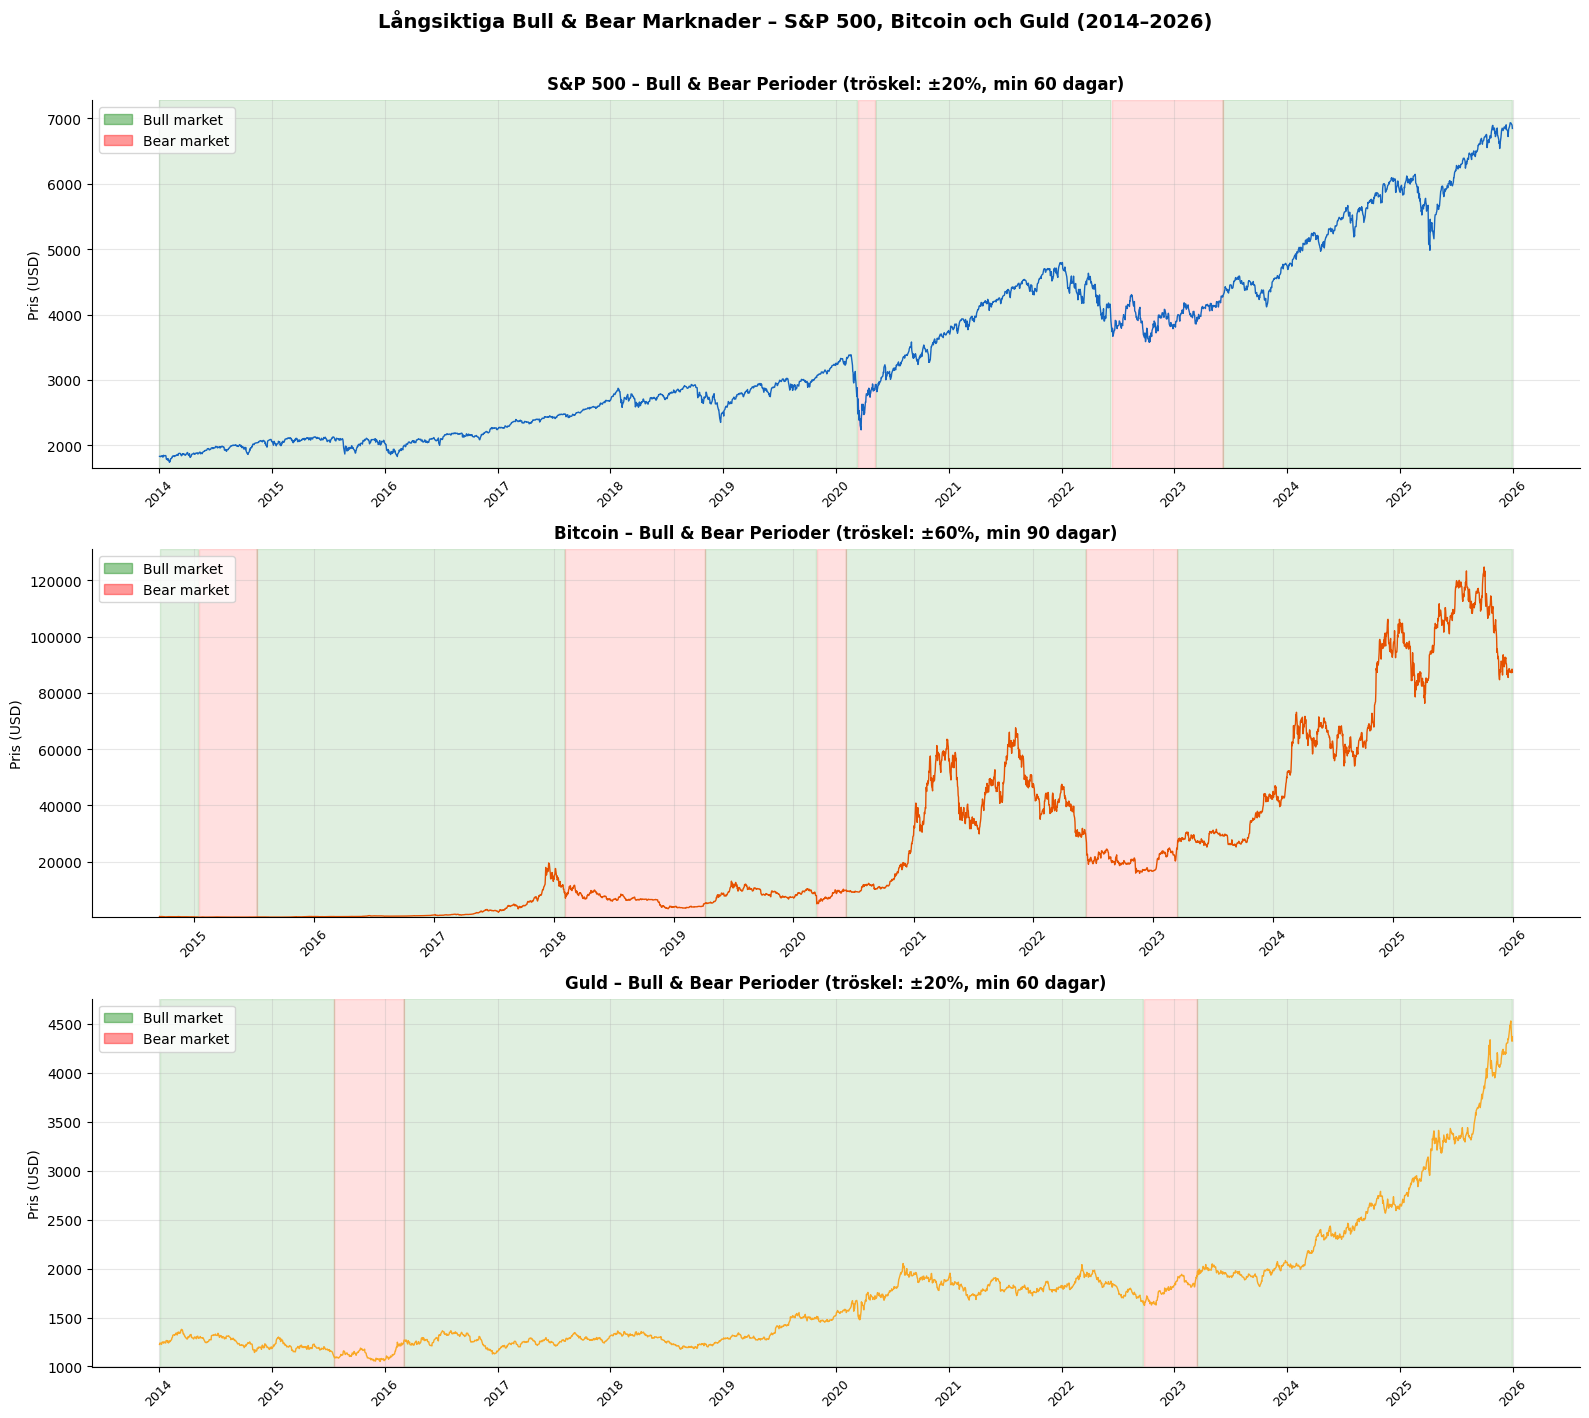

✓ Graf sparad: results/02_bull_bear_regimes.png


In [7]:
colors     = {'SP500': '#1565C0', 'Bitcoin': '#E65100', 'Gold': '#F9A825'}
labels_map = {'SP500': 'S&P 500', 'Bitcoin': 'Bitcoin', 'Gold': 'Guld'}

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=False)

for ax, (name, df) in zip(axes, assets.items()):
    close  = df['Close'].dropna()
    regime = df['Regime'].reindex(close.index)
    t      = THRESHOLDS[name]

    # Färglägg bakgrund
    ax.fill_between(close.index, close.min() * 0.95, close.max() * 1.05,
                    where=(regime == 1), alpha=0.12, color='green')
    ax.fill_between(close.index, close.min() * 0.95, close.max() * 1.05,
                    where=(regime == 0), alpha=0.12, color='red')

    # Prisutveckling
    ax.plot(close.index, close, color=colors[name], linewidth=1)

    # Titel och labels
    ax.set_title(
        f'{labels_map[name]} – Bull & Bear Perioder '
        f'(tröskel: ±{int(t["bull"]*100)}%, min {t["min_days"]} dagar)',
        fontsize=12, fontweight='bold', pad=8
    )
    ax.set_ylabel('Pris (USD)', fontsize=10)
    ax.set_ylim(close.min() * 0.95, close.max() * 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # X-axel – år för varje subplot
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45, labelsize=9)

    # Legend
    bull_patch = mpatches.Patch(color='green', alpha=0.4, label='Bull market')
    bear_patch = mpatches.Patch(color='red',   alpha=0.4, label='Bear market')
    ax.legend(handles=[bull_patch, bear_patch], fontsize=10, loc='upper left')

fig.suptitle('Långsiktiga Bull & Bear Marknader – S&P 500, Bitcoin och Guld (2014–2026)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_bull_bear_regimes.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/02_bull_bear_regimes.png')

60% för Bitcoin:
Bitcoins historiska bear markets har sett ut så här:

2014–2015: -86%

2017–2018: -84%

2021–2022: -77%

En nedgång på 40–50% händer relativt ofta inom bull markets för Bitcoin – det är normalt brus. 60% fångar de verkliga strukturella bear markets och inte tillfälliga korrektioner.

90 dagars minimum:

Bitcoin-cyklerna är långa – bull markets varar ~1000 dagar och bear markets ~365 dagar historiskt. En regim som håller kortare än 90 dagar är troligtvis en tillfällig rörelse snarare än ett verkligt skifte. 90 dagar (~3 månader) är ett rimligt filter för att säkerställa att vi fångar strukturella trender.

60 dagar för S&P 500:

Den akademiska standarden enligt Pagan & Sossounov (2003) säger att bull/bear markets ska ha en minsta varaktighet på flera månader. 60 dagar är ungefär 2 månader vilket är den nedre gränsen för vad som räknas som ett strukturellt regimskifte.

Konkret motivering:

S&P 500:

COVID-kraschen 2020 varade ~33 dagar från topp till botten – det är för kort för att räknas som en "riktig" bear market enligt långsiktig definition
Men vi vill ändå fånga den eftersom nedgången var ~34%
60 dagar gör att vi fångar COVID eftersom återhämtningen tog längre tid än 60 dagar totalt

60 dagar för S&P Guld:

Guld rör sig långsammare och mer stabilt än aktier
En regim kortare än 60 dagar för guld är nästan alltid tillfällig volatilitet
60 dagar filtrerar bort brus men fångar de verkliga trendskiftena som 2015–2016 och 2022


## 6. Identifiera specifika bull & bear perioder

Här listar vi de exakta datumen för varje regimskifte – användbart för metodkapitlet i rapporten.

In [8]:
def get_regime_periods(regime: pd.Series) -> pd.DataFrame:
    periods = []
    current = regime.iloc[0]
    start   = regime.index[0]

    for date, val in regime.items():
        if val != current:
            periods.append({
                'Typ':   'Bull' if current == 1 else 'Bear',
                'Start': start.date(),
                'Slut':  date.date(),
                'Dagar': (date - start).days
            })
            current = val
            start   = date

    periods.append({
        'Typ':   'Bull' if current == 1 else 'Bear',
        'Start': start.date(),
        'Slut':  regime.index[-1].date(),
        'Dagar': (regime.index[-1] - start).days
    })

    return pd.DataFrame(periods)


for name, df in assets.items():
    print(f'\n── {name} ──────────────────────────────────────')
    periods = get_regime_periods(df['Regime'].dropna())
    display(periods.style.map(
        lambda x: 'background-color: #c8e6c9' if x == 'Bull'
                  else ('background-color: #ffcdd2' if x == 'Bear' else ''),
        subset=['Typ']
    ))


── SP500 ──────────────────────────────────────


,Typ,Start,Slut,Dagar
0,Bull,2014-01-02,2020-03-12,2261
1,Bear,2020-03-12,2020-05-11,60
2,Bull,2020-05-11,2022-06-13,763
3,Bear,2022-06-13,2023-06-08,360
4,Bull,2023-06-08,2025-12-31,937



── Bitcoin ──────────────────────────────────────


,Typ,Start,Slut,Dagar
0,Bull,2014-09-17,2015-01-14,119
1,Bear,2015-01-14,2015-07-11,178
2,Bull,2015-07-11,2018-02-05,940
3,Bear,2018-02-05,2019-04-07,426
4,Bull,2019-04-07,2020-03-12,340
5,Bear,2020-03-12,2020-06-10,90
6,Bull,2020-06-10,2022-06-12,732
7,Bear,2022-06-12,2023-03-17,278
8,Bull,2023-03-17,2025-12-31,1020



── Gold ──────────────────────────────────────


,Typ,Start,Slut,Dagar
0,Bull,2014-01-02,2015-07-22,566
1,Bear,2015-07-22,2016-03-04,226
2,Bull,2016-03-04,2022-09-26,2397
3,Bear,2022-09-26,2023-03-17,172
4,Bull,2023-03-17,2025-12-31,1020


## 7. Beräkna daglig avkastning

Vi beräknar den dagliga procentuella förändringen i stängningspriset.  
Daglig avkastning används som feature i ML-modellerna och för statistisk analys.

In [11]:
for name, df in assets.items():
    assets[name]['Return'] = df['Close'].pct_change()

    bull_ret = df.loc[df['Regime'] == 1, 'Return'].mean() * 100
    bear_ret = df.loc[df['Regime'] == 0, 'Return'].mean() * 100

    print(f'{name}:')
    print(f'  Genomsnittlig daglig avkastning – Bull: {bull_ret:+.3f}%  Bear: {bear_ret:+.3f}%')

SP500:
  Genomsnittlig daglig avkastning – Bull: +0.047%  Bear: +0.074%
Bitcoin:
  Genomsnittlig daglig avkastning – Bull: +0.231%  Bear: +0.057%
Gold:
  Genomsnittlig daglig avkastning – Bull: +0.040%  Bear: +0.109%


S&P 500 och Guld Bear har högre avkastning än Bull, förklaringen är enkel bear perioderna inkluderar återhämtningsfasen.
När vi definierade bear market med 20% regeln så räknas perioden från när det börjar falla tills det stigit 20% igen. Det betyder att slutet av bear perioden faktiskt innehåller en kraftig uppgång vilket drar upp genomsnittet.
Det är ett känt problem med regelbaserad etikettering, etiketterna är bakåtblickande.

Bitcoin Bull har mycket högre avkastning
Bitcoin är det enda som beter sig "rätt"  bull dagar har +0.231% per dag mot +0.057% under bear. Det stämmer med halverings-cyklerna där bull markets är kraftiga och snabba uppgångar.


## 8. Spara etiketterad data

In [12]:
for name, df in assets.items():
    filename = f'{name.lower()}_labeled.csv'
    filepath = os.path.join(DATA_DIR, filename)
    df.to_csv(filepath)
    print(f'✓ Sparad: data/{filename}  ({len(df)} rader, kolumner: {list(df.columns)})')

✓ Sparad: data/sp500_labeled.csv  (3018 rader, kolumner: ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return'])
✓ Sparad: data/bitcoin_labeled.csv  (4124 rader, kolumner: ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return'])
✓ Sparad: data/gold_labeled.csv  (3017 rader, kolumner: ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return'])


## 9. Sammanfattning

| Tillgång | Bull-dagar | Bear-dagar | Bull % | Bear % |
|----------|-----------|-----------|--------|--------|
| S&P 500  | 2729      | 289       | 90.4%  | 9.6%   |
| Bitcoin  | 3152      | 972       | 76.4%  | 23.6%  |
| Guld     | 2742      | 275       | 90.9%  | 9.1%   |

**Trösklar som användes:**

| Tillgång | Bear-tröskel | Bull-tröskel | Min. varaktighet |
|----------|-------------|-------------|------------------|
| S&P 500  | -20%        | +20%        | 60 dagar         |
| Bitcoin  | -60%        | +60%        | 90 dagar         |
| Guld     | -20%        | +20%        | 60 dagar         |

**Viktiga observationer:**
- S&P 500 och Guld är i bull market ~90% av perioden 2014–2026,
  vilket speglar en historiskt stark bull-period
- Bitcoin visar tydliga cykliska mönster kopplade till halveringarna
  med ~76% bull och ~24% bear
- De identifierade bear-perioderna stämmer väl med kända händelser:
  COVID-19 (mars 2020), kryptovintern (2018), FTX-kollaps (2022),
  räntehöjningar (2022)

**Nästa steg:** `03_feature_engineering.ipynb` skapa tekniska
indikatorer och features för ML-modellerna.